<h3> Wstęp do testowania hipotez

Idea testów statystycznych: 
- Formułujemy hipotezy $H_0$ oraz $H_1$ 
- na podstawie danych wyznaczana jest pewna statystyka testowa $X$
- przy założeniu hipotezy zerowej wiemy jaki jest rozkład $X$
- patrzymy na ile wartość statystyki testowej $X$ jest typowa (zgodna z rozkładem) -> wyznaczamy wartość $p-value$
- jeżeli $p-value$ niskie (mniejsze od przyjętego poziomu istotności $\alpha$), to odrzucamy $H_0$

<h4> Testowanie średniej

<h4> Jedna próba

In [1]:
dane = c(87.7,80.01,77.28,78.76,81.52,74.2,80.71,79.5,77.87,81.94,80.7,
    82.32,75.78,80.19,83.91,79.4,77.52,77.62,81.4,74.89,82.95,
    73.59,77.92,77.18,79.83,81.23,79.28,78.44,79.01,80.47,76.23,
    78.89,77.14,69.94,78.54,79.7,82.45,77.29,75.52,77.21,75.99,
    81.94,80.41,77.7)

Testujemy hipotezę $H_0: \mu = 80$ przeciw $H_A: \mu < 80$

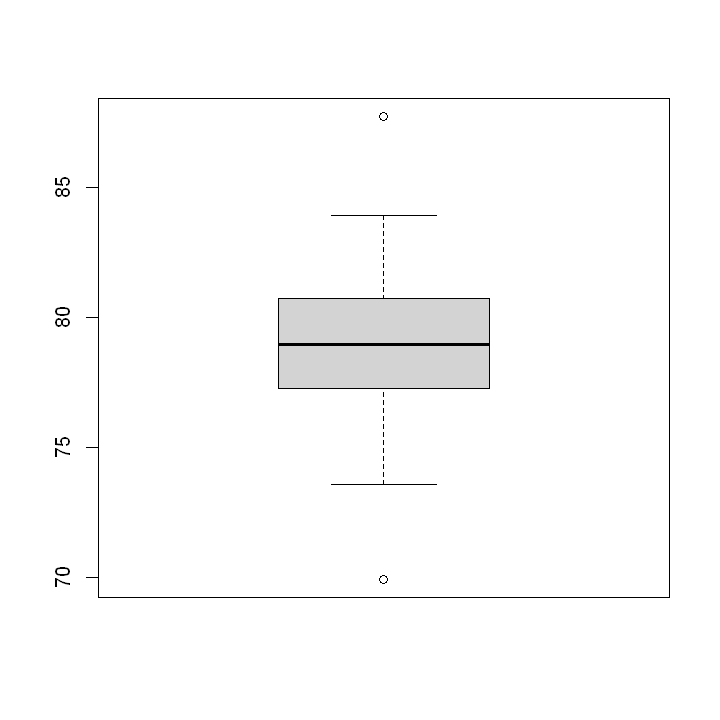

In [2]:
options(repr.plot.width=6, repr.plot.height=6) 
boxplot(dane)

In [3]:
mean(dane); sd(dane)

[1] 78.91068

[1] 3.056023

Wyznaczamy statystykę $T = \frac{\overline{X}-\mu}{\sigma/\sqrt{n}}$. Przy małej próbie ma rozkład $t(n-1)$, przy większej można przyjąć $N(0,1)$.

In [4]:
T = (mean(dane) - 80)/(sd(dane)/sqrt(length(dane)))
print(T)

[1] -2.364419


In [5]:
print(t.test(x=dane, mu=80, alternative="less")) #p_value<0.05, wiec odrzucamy H0 (przyjmujac prog 0.05)


	One Sample t-test

data:  dane
t = -2.3644, df = 43, p-value = 0.01132
alternative hypothesis: true mean is less than 80
95 percent confidence interval:
     -Inf 79.68517
sample estimates:
mean of x 
 78.91068 



Testujemy hipotezę $H_0: \mu = 80$ przeciw $H_A: \mu  \neq 80$

In [6]:
t.test(x=dane, mu=80, alternative="two.sided") #p_value<0.05, wiec odrzucamy H0 (przyjmujac prog 0.05)


	One Sample t-test

data:  dane
t = -2.3644, df = 43, p-value = 0.02264
alternative hypothesis: true mean is not equal to 80
95 percent confidence interval:
 77.98157 79.83980
sample estimates:
mean of x 
 78.91068 


In [6]:
print(t.test(x=dane, mu=80, alternative="two.sided")$conf.int) #przedzial ufnosci dwustronny (na 95%)

[1] 77.98157 79.83980
attr(,"conf.level")
[1] 0.95


<h4> Zadanie1: W telewizji ogłoszono, że cena metra kwadratowego mieszkania w mieście $X$ kosztuje średnio 15.2 tys. złotych. Aby to zweryfikować wybrano 14 losowych mieszkań. Ceny przedstawiały się następująco: 15.00, 15.56, 20.36, 15.08, 14.12, 11.28, 12.64, 11.16, 17.36, 14.44, 17.24, 13.24, 10.00, 13.08. Czy te wartości potwierdzają postawioną tezę?

<h4> Dwie próby

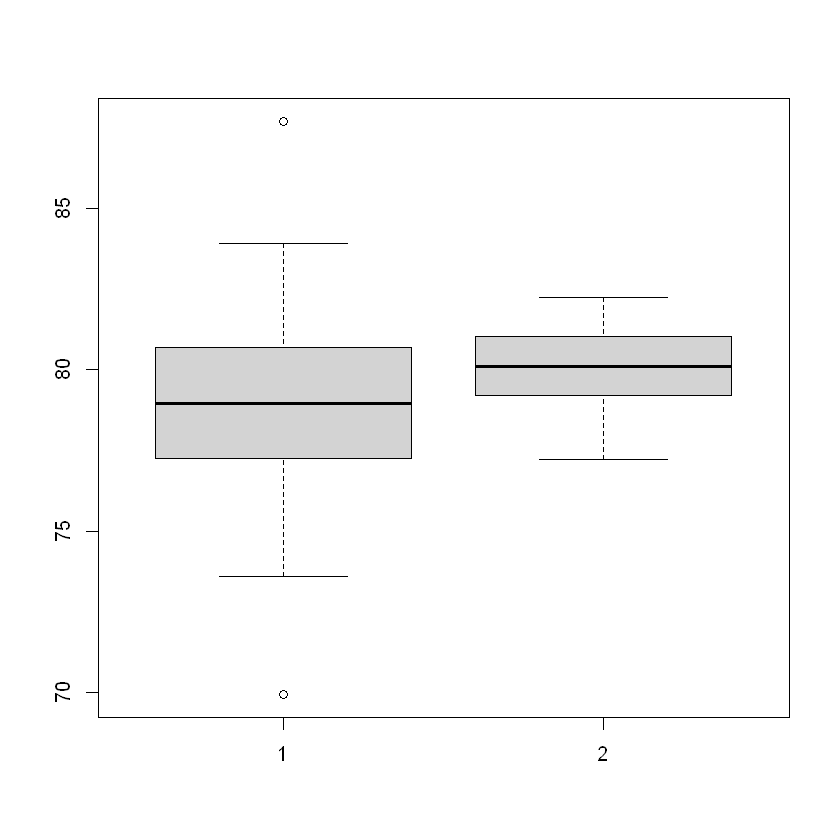

In [16]:
dane1 = c(87.7,80.01,77.28,78.76,81.52,74.2,80.71,79.5,77.87,81.94,80.7,
    82.32,75.78,80.19,83.91,79.4,77.52,77.62,81.4,74.89,82.95,
    73.59,77.92,77.18,79.83,81.23,79.28,78.44,79.01,80.47,76.23,
    78.89,77.14,69.94,78.54,79.7,82.45,77.29,75.52,77.21,75.99,
    81.94,80.41,77.7)

dane2 =  c(80.22,79.73,81.1,78.76,82.03,81.66,80.97,81.32,80.12,78.98,
    79.21,81.48,79.86,81.06,77.96,80.73,80.34,80.01,81.82,79.3,
    79.08,79.47,78.98,80.87,82.24,77.22,80.03,79.2,80.95,79.17,81)

boxplot(dane1,dane2)

In [10]:
mean(dane1);sd(dane1);mean(dane2);sd(dane2)

[1] 78.91068

[1] 3.056023

[1] 80.1571

[1] 1.213695

Testujemy hipotezę $H_0: \mu_1 = \mu_2$ przeciw alternatywnej $H_1: \mu_2 > \mu_1$.

In [21]:
t.test(x=dane2,y=dane1,alternative="greater", conf.level=0.95) #tutaj odrzucamy H_0


	Welch Two Sample t-test

data:  dane2 and dane1
t = 2.4455, df = 60.091, p-value = 0.008706
alternative hypothesis: true difference in means is greater than 0
95 percent confidence interval:
 0.3949381       Inf
sample estimates:
mean of x mean of y 
 80.15710  78.91068 


<h4> Zadanie2: Testujemy skuteczność leku skutkującego redukcją tętna. Pomiary tej wielkości zostały dokonane na 16 osobnikach (w uderzeniach na minutę). Pomiaru dokonano przed podaniem leku i po pewnym czasie.

In [10]:
rate.before = c(52,66,89,87,89,72,66,65,49,62,70,52,75,63,65,61)
rate.after = c(51,66,71,73,70,68,60,51,40,57,65,53,64,56,60,59)

<h4> Czy istnieje istotna statystycznia różnica po spożyciu leku? W tym celu zdefiniuj nowy wektor $rate.dif$ określający różnicę w uderzeniach (po - przed) dla kolejnych osobników, a następnie przetestuj hipotezę $H_{\mu_{rate.dif}} =0$ przeciw hipotezie $H_{\mu_{rate.diff}}<0$.

<h4> Zadanie3: W pakiecie $MASS$ znajdują się dane $anorexia$. Dane dotyczą 72 młodych kobiet i zawierają informacje o wadze (w funtach) przed i po leczeniu. Osoby zostały podzielone na 3 kategorie - kontrola (bez leczenia) oraz 2 grupy ze względu na sposób leczenia. Dokładniej:
    
- Cont = control
 
- CBT = cognitive behavioral program
    
- FT = family treatment
    
Niech $X = X_{post} - X_{pre}$. Zbadaj hipotezę $\mu_{X} =0$ przeciw $\mu_{X} >0$ (dla każdej grupy). Skomentuj otrzymane wyniki.

In [11]:
library(MASS)
head(anorexia)
summary(anorexia)

Treat,Prewt,Postwt
Cont,80.7,80.2
Cont,89.4,80.1
Cont,91.8,86.4
Cont,74.0,86.3
Cont,78.1,76.1
Cont,88.3,78.1


  Treat        Prewt           Postwt      
 CBT :29   Min.   :70.00   Min.   : 71.30  
 Cont:26   1st Qu.:79.60   1st Qu.: 79.33  
 FT  :17   Median :82.30   Median : 84.05  
           Mean   :82.41   Mean   : 85.17  
           3rd Qu.:86.00   3rd Qu.: 91.55  
           Max.   :94.90   Max.   :103.60  

<h4> Zadanie4: Rozważ dane $PlantGrowth$ (rozważane już na ćw2) dotyczące produkcji pewnych roślin. Zastosowano 2 rodzaje suplementów aby zwiększyć produkcję (trt1 i trt2). Czy rzeczwyiście średnia produkcja w grupach trt1 i trt2 jest większa niż ta w grupie bez suplementacji? Wykonaj dwa testy - ctrl vs trt1 oraz ctrl vs trt2. Skomentuj otrzymane wyniki.

In [12]:
head(PlantGrowth); summary(PlantGrowth)

weight,group
4.17,ctrl
5.58,ctrl
5.18,ctrl
6.11,ctrl
4.50,ctrl
4.61,ctrl


     weight       group   
 Min.   :3.590   ctrl:10  
 1st Qu.:4.550   trt1:10  
 Median :5.155   trt2:10  
 Mean   :5.073            
 3rd Qu.:5.530            
 Max.   :6.310            

<h4> Testowanie proporcji

<h4> Jedna próba

In [10]:
glosy = c(0,0,1,1,0,0,0,0,0,1,0,0,0,0,0,0,0,0,1,0,0,0,1,1,1,0,0,0,1)

In [11]:
length(glosy); mean(glosy)

[1] 29

[1] 0.2758621

Testujemy hipotezę $H_0: \pi = 0.2$ przeciw $H_A: \pi \neq 0.2$

Statystyka $Z = \frac{p^* - \pi}{\sqrt{\pi(1-\pi)/n}}$. Pod pewnymi założeniami $Z \sim N(0,1)$.

In [12]:
Z = (mean(glosy) - 0.2)/sqrt(0.2*(1-0.2)/29)
print(Z)

[1] 1.021324


In [13]:
prop.test(x=sum(glosy), n=length(glosy), p=0.2, correct=FALSE) #ten test  formalnie uzywa rozkładu chi kwadrat dlatego statystyka jest nieco inna, ale idea podobna


	1-sample proportions test without continuity correction

data:  sum(glosy) out of length(glosy), null probability 0.2
X-squared = 1.0431, df = 1, p-value = 0.3071
alternative hypothesis: true p is not equal to 0.2
95 percent confidence interval:
 0.1469876 0.4571713
sample estimates:
        p 
0.2758621 


<h4> Zadanie5: Zwielokrotnij 5-krotnie wektor $glosy$ i przeprowadź analogiczne testowanie. Skomentuj zmienioną wartosć $p-value$. Z czego wynika?

<h4> Dwie próby

Testujemy hipotezę $H_0: \pi_1 = \pi_2$ przeciw alternatywnej $H_1: \pi_2 > \pi_1$.

In [17]:
#pi = x/n

x1 = 180
n1 = 233

x2 = 175
n2 = 197

x1/n1; x2/n2

[1] 0.7725322

[1] 0.8883249

In [18]:
prop.test(x=c(x2,x1), n=c(n2,n1), alternative="greater", correct=FALSE)


	2-sample test for equality of proportions without continuity
	correction

data:  c(x2, x1) out of c(n2, n1)
X-squared = 9.9395, df = 1, p-value = 0.0008089
alternative hypothesis: greater
95 percent confidence interval:
 0.05745804 1.00000000
sample estimates:
   prop 1    prop 2 
0.8883249 0.7725322 


<h4> Zadanie6: Badacze analizują częstość występowania polimorfizmu SNP w genie TP53 w dwóch populacjach. Allel A (dziki typ) i allel G (wariant) występują z różnymi częstościami w grupie pacjentów z rakiem oraz w grupie kontrolnej.

Dane:
- W populacji pacjentów z rakiem: 120 osób ma allel G, a 380 ma allel A.
- W populacji kontrolnej: 90 osób ma allel G, a 410 ma allel A.

Pytanie:
Czy częstość allelu G różni się istotnie między populacją pacjentów z rakiem a grupą kontrolną?

<h4> Zmienne kategoryczne

In [19]:
d = c(2,3,2,3,2,1,3,3,2,2,3,2,2,2,3,3,3,2,3,2,2,2,1,3,2,2,2,1,2,2,3,2,2,2,2,1,2,1,1,1,2,2,2,3,1,2,1,2,1,2,1,3,3)
print(factor(d))

 [1] 2 3 2 3 2 1 3 3 2 2 3 2 2 2 3 3 3 2 3 2 2 2 1 3 2 2 2 1 2 2 3 2 2 2 2 1 2 1
[39] 1 1 2 2 2 3 1 2 1 2 1 2 1 3 3
Levels: 1 2 3


Testujemy hipotezę $H_0: \pi_1 = \pi_2 = \pi_3$ przeciw $H_A = \sim H_0$

In [20]:
print(table(d))

d
 1  2  3 
11 28 14 


In [21]:
table(d)/length(d) #częstosci

d
        1         2         3 
0.2075472 0.5283019 0.2641509 

In [22]:
expected =  1/3*length(d) #expected = oczekiwane

dane.matrix = cbind(1:3,table(d), expected,(table(d)-expected)^2/expected)
dimnames(dane.matrix) <- list(c("1","2","3"),c("i","Oi","Ei","(Oi-Ei)^2/Ei"))

print(dane.matrix)

  i Oi       Ei (Oi-Ei)^2/Ei
1 1 11 17.66667    2.5157233
2 2 28 17.66667    6.0440252
3 3 14 17.66667    0.7610063


In [23]:
2.5157233 + 6.0440252 + 0.7610063

[1] 9.320755

In [24]:
chisq.test(x=table(d)) #czy zachodzi jednostajny rozklad?


	Chi-squared test for given probabilities

data:  table(d)
X-squared = 9.3208, df = 2, p-value = 0.009463


In [25]:
chisq.test(x=table(d), p=c(0.25,0.5,0.25)) #H0: p=c(0.25,0.5,0.25)


	Chi-squared test for given probabilities

data:  table(d)
X-squared = 0.50943, df = 2, p-value = 0.7751


<h4> Zadanie7: Reklama kremu do skóry twierdzi, że 9 na 10 kobiet które używało ich produktu zarekomendowało by go swoim znajomym. Sceptyczna klientka uważa, że rzeczywista proporcja jest mniejsza. Zebrała one dane od 89 losowych kobiet. 71 z nich potwierdziło zadowolenie. Postaw odpowiednią hipotezę, a następnie na poziomie istotności $\alpha = 0.1$ odpowiedz na nurtujące klientkę pytanie.

<h4> Test niezależności

In [28]:
#355 pacjentow, zabiegi/poziom sukcesu
skin <- matrix(c(20,32,8,52,9,72,8,32,16,64,30,12),4,3, dimnames=list(c("Injection","Tablet","Laser","Herbal"), c("None","Partial","Full")))
print(skin)

          None Partial Full
Injection   20       9   16
Tablet      32      72   64
Laser        8       8   30
Herbal      52      32   12


In [29]:
kr <- nrow(skin)
kc <- ncol(skin)
rowSums(skin);  colSums(skin)

Injection    Tablet     Laser    Herbal 
       45       168        46        96

None Partial    Full 
    112     121     122

In [30]:
chisq.test(x=skin) #H0: zmienne są niezalezne; (tutaj: typ leczenia i poziom sukcesu nie są niezalezne)


	Pearson's Chi-squared test

data:  skin
X-squared = 66.166, df = 6, p-value = 2.492e-12


* Uwaga: chisq.test bierze pod uwagę wszystkie kombinacje kategorii, co może prowadzić do sytuacji, w której lokalne różnice potencjalnie wykrywane przez prop.test() rozmyją się w globalnym teście chi-kwadrat.



<h4> Zadanie8
Poniżej przedstawiono wyniki badania dotyczącego polimorfizmu SNP 8390G>A w genie APOE w trzech grupach:

- 100 pacjentów z chorobą Alzheimera (AD)

- 100 pacjentów z chorobą Parkinsona (PD)

- 150 zdrowych osób (grupa kontrolna)

Pytania
- wykonaj test chi-kwadrat aby sprawdzić czy jest związek między genotypem a grupą pacjentów. Skomentuj otrzymane wyniki.
- za pomocą prop.test porównaj częstości występownia genotypu GG pomiędzy kontrolą a pacjentami z chorobą Alzheimera oraz  kontrolą a pacjentami z chorobą Parkinsona. Czy różnice są istotne statystycznie? Skomentuj otrzymane wyniki.


In [5]:
#opracowano na podstawie: https://www.sciencedirect.com/science/article/pii/S1110863015001226
SNP_data = matrix(c(16,14,15, 
                    34,32,39, 
                    50,54,96), 
                    nrow = 3, byrow = TRUE)

rownames(SNP_data) = c("AA", "AG", "GG")
colnames(SNP_data) = c("Alzehimer", "Parkinson", "Kontrola")

print(SNP_data)

   Alzehimer Parkinson Kontrola
AA        16        14       15
AG        34        32       39
GG        50        54       96


<h3> Uzupełnienie

<h4> Rozkład chi kwadrat o n stopniach swobody

In [29]:
options(repr.plot.width=6, repr.plot.height=4)

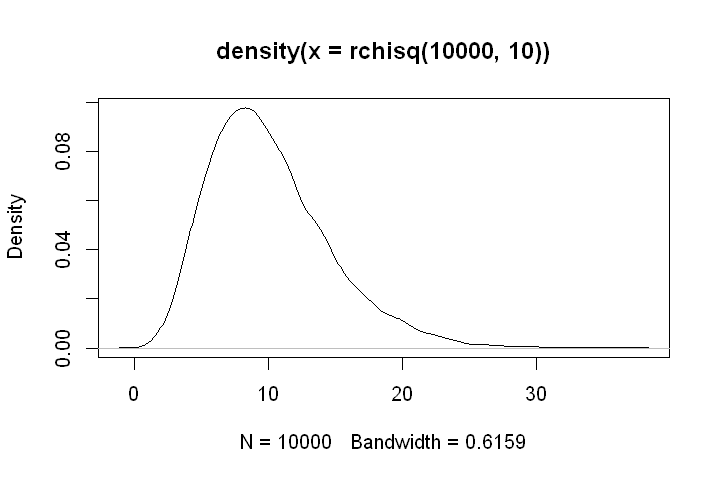

In [30]:
plot(density(rchisq(10000, 10)))

<h4> Rozkład t-studenta o n stopniach swobody

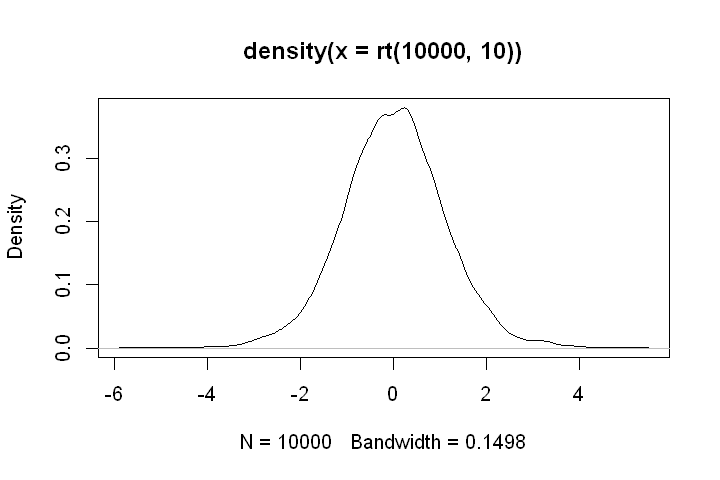

In [36]:
plot(density(rt(10000, 10)))

<h4> Zadanie9: Policz kurtozę i skośność dla rozkładu chi-kwadrat i t-studenta z 10 stopniami swobody (na podstawie próby 1000 elementowej). Ile wynosiły odpowiednie wartości dla rozkładu $N(0,1)$? 